In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def admissibility_split(MP, a, return_P=False, subspace=False, consistency = True, with_edges=False):
    level={1:5, 2:5, 3:5, 4:5, 5:5, 6:5, 7:5}
    marked = set()
    mapped = lambda x: 1 if x in (0, 1) else 0
    num_split=0
    assert isinstance(a,dict) and len(a)==len(MP.mesh.domains), 'Invalid type for diffusion coefficient'
    if return_P:
        P = scipy.sparse.identity(MP.nLocDofs)
    while True:
        for p in range(MP.mesh.numpatches):
            for b in range(4):
                kv = MP.mesh.kvs[p][mapped(b)]
                deg = kv.p
                s1,s2 = kv.support()
                nodes = np.clip(MP.mesh.boundaries(p)[1][b],kv.kv[0],kv.kv[-1])
                m = min(nodes[1:]-nodes[:-1])
                if not bspline_cy.pyx_checkSWcondition(kv.kv, kv.p, len(kv.kv), nodes, len(nodes), with_edges) or (s2-s1)/m>2**level[deg]-1:
                    marked.add(p)
        if consistency:
            for (p1,b1) in MP.mesh.L_intfs:
                if len(MP.mesh.L_intfs[(p1,b1)])>1:
                    p2 = MP.mesh.L_intfs[(p1,b1)][0][0]
                    if a[MP.mesh.patch_domains[p1]] + 1e-3 < a[MP.mesh.patch_domains[p2]]:
                        marked.add(p1)
        if len(marked)>0:
            num_split+=len(marked)
            if return_P:
                P = MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace) @ P
            else:
                MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace)
            marked=set()
        else:
            break
    if consistency:
        print("Split {} additional patches due to admissibility and consistency".format(num_split))
    else:
        print("Split {} additional patches due to admissibility".format(num_split))
    if return_P:
        return P

In [3]:
def Inductor(deg,N, airgap=0.025, thin=False):
    kvs=42*[2*(bspline.make_knots(deg,0.0,1.0,N),)]
    
    geos=[      
        geometry.unit_square().scale((0.5)).translate((-0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,-0.5)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,-0.5)),
        geometry.unit_square().scale(0.5).translate((1.5,-0.5)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0)),
        geometry.unit_square().scale(0.25),
        geometry.unit_square().scale(0.25).translate((0.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0)),
        
        geometry.unit_square().scale((0.5,airgap)).translate((-0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((1.5,0.25)),
        
        geometry.unit_square().scale((0.5,0.5)).translate((-0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((1.5,0.25+airgap)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0.75+airgap)),
        
        geometry.unit_square().scale(0.5).translate((-0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,1.0+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,1.0+airgap)),
        geometry.unit_square().scale(0.5).translate((1.5,1.0+airgap)),
         ]
    patches=list(zip(kvs,geos))
    M = topology.MultiPatch(patches)
    M.rename_domain(0,'Air')
    M.set_domain_id({'Fe':{8,9,10,11,12,22,24,26,29,30,31,32,33}, 'C1':{23}, 'C2':{25}})
    if not thin:
        M.h_refine({i:1 for i in range(14,21)});                                        #split airgap patches further in y-axis to make up for anisotropy 
        M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))});               #split airgap patches further in y-axis to make up for anisotropy 
    #M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))+list(range(49,63))}); #split airgap patches further in y-axis to make up for anisotropy
    return M

In [4]:
mu0 = 4.344*np.pi*1e-7
nu = {'C1': 1/mu0, 'C2':1/mu0, 'Fe':1/(2500*mu0), 'Air': 1/mu0}
j = {'C1': lambda x,y: 66/(0.125), 'C2':lambda x,y: -66/(0.125), 'Fe':lambda x,y: 0.0, 'Air': lambda x,y: 0.0}
MaT = {'C1': lambda x,y: (0.,0.), 'C2': lambda x,y:(0.,0.), 'Fe':lambda x,y:(0.,0.), 'Air': lambda x,y:(0.,0.)}
dir_data = {0:0}

In [13]:
degs = (2,)
maxpatches =(4000,3500,3000)
level = (4,4,4)
#maxpatches=(1500,)
maxiter=(1,2,2)
#maxiter=(20,23,25)
R = np.zeros((30,5*len(degs)))
max_k=0
consistency = False
Prec='S'
plot=0
prim = {'v':1, 'e':1}
thin=1
eps=1e-7

for i,deg in enumerate(degs):
    eta = 1
    N = 2*deg + 1
    M = Inductor(deg,N,thin=thin)
    
    IMap = ieti.IetiMapper(M, dir_data)
    admissibility_split(IMap, return_P = False, subspace=False, consistency=consistency, a=nu, with_edges = prim['e']);
    #IMap.mesh.plotmesh();

    print("======================================================")
    print("deg = "+str(deg))
    k=0
    while k < maxiter[i]:
        print(k)
        print("Number of patches: {}".format(IMap.nPatches))
        if plot:
            M.plotmesh(figsize=(8,8),color={'C1':'yellow', 'C2':'yellow', 'Fe':'darkgrey', 'Air':'white'}, knots=0, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            #plt.savefig('/home/wolfman/Pictures/Inductor/p'+str(deg)+'/i'+str(k)+'.pdf',bbox_inches='tight');
            #plt.close();
            plt.show()
        
        ### Solve
        IMap.parametersort(nu)
        A, RHS = IMap.assemble(a=nu,f=j, M=None)
        N = [A.shape[0] for A in A]

        Prim = csc_matrix((IMap.N_ofs_elim[-1],0))

        if bool(prim['v']):
            PrimV, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)
            Prim = scipy.sparse.hstack([Prim, PrimV])
        if bool(prim['e']):
            Prim = scipy.sparse.hstack([Prim, IMap.interface_averages_as_primals(level[i])])

        print(Prim.shape)
        B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
        SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

        nPrim=Prim.shape[1]

        R[k,i*5+3]=nPrim
        R[k,i*5+4]=IMap.nPatches

        primal = ieti.PrimalSystem(Prim)
        modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    
        loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
        modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
        loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
        I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver)
        F, b = I.SchurComplement(), I.RHSforSchurComplement()

        if Prec=='S':
            SD.setupSelectionScaling()
            P = SD.AsOperator()
        elif Prec=='D':
            SD.SchurAsMatrices()
            P=ieti.EdgePreconditioner(IMap, SD.S_dense, SD.B ,C)
        else:
            print('error')
        
        lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=P, output=1, rtol=1e-8, atol=1e-12)
        R[k,i*5+1] = it
        R[k,i*5+2] = max_eig/min_eig

        uh = I.constructSolutionFromLagrangeMultipliers(lam)
        uh = primal.distributePrimalSolution(uh)
        uh = np.concatenate(IMap.completeDirichlet(uh))
            
        err_ind=adaptive.mp_resPois(IMap, uh, nu=nu, f=j)
        eta = np.linalg.norm(err_ind)
        #eta.append(eta)
        R[k,i*5] = eta
        #print(eta[-1]/Eerr)

        print("Error Estimator: {:.3}".format(eta))
        marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        marked_patches = {p:None for p in marked_patches}

        if IMap.nPatches + 3*len(marked_patches) >= maxpatches[i]:
            break;

        if eta < eps:
            break;

        P = IMap.h_refine(h_ref=marked_patches,ref="rs", return_P = False, in_subspace=False)

        admissibility_split(IMap, return_P = False, subspace=False, consistency=consistency, a=nu, with_edges = prim['e']);

        k+=1
        print("#####################################################")

    max_k=max(k,max_k)

R=R[:max_k,:]
if prim['e']:
    if thin:
        if consistency:
            np.save("Inductor_"+Prec+"_B_consistency_thin",R)
        else:
            np.save("Inductor_"+Prec+"_B_thin",R)
    else:
        if consistency:
            np.save("Inductor_"+Prec+"_B_consistency",R)
        else:
            np.save("Inductor_"+Prec+"_B",R)
else:
    if thin:
        if consistency:
            np.save("Inductor_"+Prec+"_A_consistency_thin",R)
        else:
            np.save("Inductor_"+Prec+"_A_thin",R)
    else:
        if consistency:
            np.save("Inductor_"+Prec+"_A_consistency",R)
        else:
            np.save("Inductor_"+Prec+"_A",R)

setting up constraints took 0.05369281768798828 seconds.
Split 0 additional patches due to admissibility
deg = 2
0
Number of patches: 42
(2058, 101)
pcg with preconditioned condition number κ ~ 3.657e+09 stopped after 666 iterations with relres 5.891e-09 after 4.93 seconds.
Error Estimator: 3.05
setting up constraints took 0.09189367294311523 seconds.
Split 0 additional patches due to admissibility
#####################################################


In [6]:
RS = np.load('Inductor_S_A.npy')
RD = np.load('Inductor_D_A.npy')

In [9]:
RD.shape

(25, 15)

In [10]:
R = np.zeros((25,16))
R[:,0]=np.arange(25)
R[:,np.array([1,2,3,6,7,8,11,12,13])]=RS[:,np.array([0,1,2,5,6,7,10,11,12])]
R[:,np.array([4,5,9,10,14,15])]=RD[:,np.array([1,2,6,7,11,12])]
np.savetxt('Inductor_A', R, fmt=('%d',)+len(degs)*('%1.1e','%d','%1.1f','%d','%1.1f'), delimiter = ' & ', newline='\\\\\n')

In [ ]:
np.load('Inductor')

In [16]:
i=0
RS[:,i]-RD[:,i]

array([-3.88799e-08,  4.79295e-08,  4.61921e-08,  1.63341e-08, -2.12030e-08, -6.87701e-10, -1.42387e-08, -9.55805e-09, -1.02652e-08, -1.08768e-08, -7.49557e-09, -7.01353e-09, -7.24049e-09, -5.29589e-09, -4.83616e-09, -5.18838e-09, -6.36240e-09, -7.97809e-09, -2.17205e-09, -2.51895e-09, -3.59442e-10, -3.37221e-12,  7.79910e-10])

In [30]:
N=2
M = topology.MultiPatch([(2*(bspline.make_knots(deg,0,1,N),),geometry.unit_square())])

In [235]:
def Kellogg(deg,N):
    M = topology.MultiPatch([(2*(bspline.make_knots(deg,0,1,N),),geometry.unit_square())])
    M.h_refine();
    M.set_domain_id({1:{0}})
    M.h_refine();
    M.h_refine();
    M.h_refine();
    return M

In [299]:
M = Kellogg(2,10)
nu={0:1.0,1:100}
j = {0:1.0,1:10.0}

In [293]:
deg=2
M = Inductor(deg,2*deg+1,thin=1,airgap=0.2)
mu0 = 4.344*np.pi*1e-7
nu = {'C1': 1/mu0, 'C2':1/mu0, 'Fe':1/(2500*mu0), 'Air': 1/mu0}
j = {'C1': lambda x,y: 66/(0.125), 'C2':lambda x,y: -66/(0.125), 'Fe':lambda x,y: 0.0, 'Air': lambda x,y: 0.0}

In [300]:
E = True
IMap = ieti.IetiMapper(M, dir_data={0:0})
admissibility_split(IMap, return_P = False, subspace=False, consistency=True, a=nu, with_edges = E);
IMap.parametersort(nu)
A, RHS = IMap.assemble(a=nu,f=j, M=None)
N = [A.shape[0] for A in A]

setting up constraints took 0.38335585594177246 seconds.
Split 0 additional patches due to admissibility and consistency


In [301]:
PrimV, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)
Prim = PrimV
if E:
    PrimE = IMap.interface_averages_as_primals()
    Prim = scipy.sparse.hstack([Prim,PrimE])

In [302]:
B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

In [303]:
primal = ieti.PrimalSystem(Prim)
modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    
loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver)
F, b = I.SchurComplement(), I.RHSforSchurComplement()

In [304]:
#SD.setupSelectionScaling()
SD.setupCoefficientScaling(nu)
P = SD.AsOperator()

lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=P, output=1, rtol=1e-8, atol=1e-12)

pcg with preconditioned condition number κ ~ 1.656 stopped after 9 iterations with relres 5.411e-09 after 0.695 seconds.


In [227]:
C[41].toarray()

array([[1.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ],
       [0.16667, 0.33333, 0.33333, 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ],
       [0.16667, 0.     , 0.     , 0.33333, 0.     , 0.     , 0.33333, 0.     , 0.     ]])

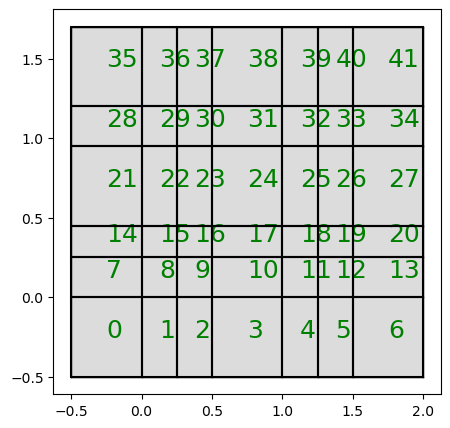

In [287]:
M.plotmesh(patch_idx=1)